K线表征结果:
K线 0 和 1: OVERLAP
K线 1 和 2: OVERLAP
K线 2 和 3: UPWARD_GAP
  缺口类型: upward, 大小: 0.02000000000000135
K线 3 和 4: CONTAINED
K线 4 和 5: CONTAINED
K线 5 和 6: CONTAINING
K线 6 和 7: UPWARD_GAP
  缺口类型: upward, 大小: 0.129999999999999
K线 7 和 8: OVERLAP
K线 8 和 9: OVERLAP
K线 9 和 10: OVERLAP
K线 10 和 11: OVERLAP
K线 11 和 12: CONTAINED
K线 12 和 13: CONTAINED
K线 13 和 14: OVERLAP
K线 14 和 15: OVERLAP
K线 15 和 16: OVERLAP
K线 16 和 17: OVERLAP
K线 17 和 18: OVERLAP
K线 18 和 19: OVERLAP
K线 19 和 20: OVERLAP
K线 20 和 21: OVERLAP
K线 21 和 22: OVERLAP
K线 22 和 23: OVERLAP
K线 23 和 24: OVERLAP
K线 24 和 25: CONTAINED
K线 25 和 26: OVERLAP
K线 26 和 27: CONTAINED
K线 27 和 28: OVERLAP
K线 28 和 29: OVERLAP


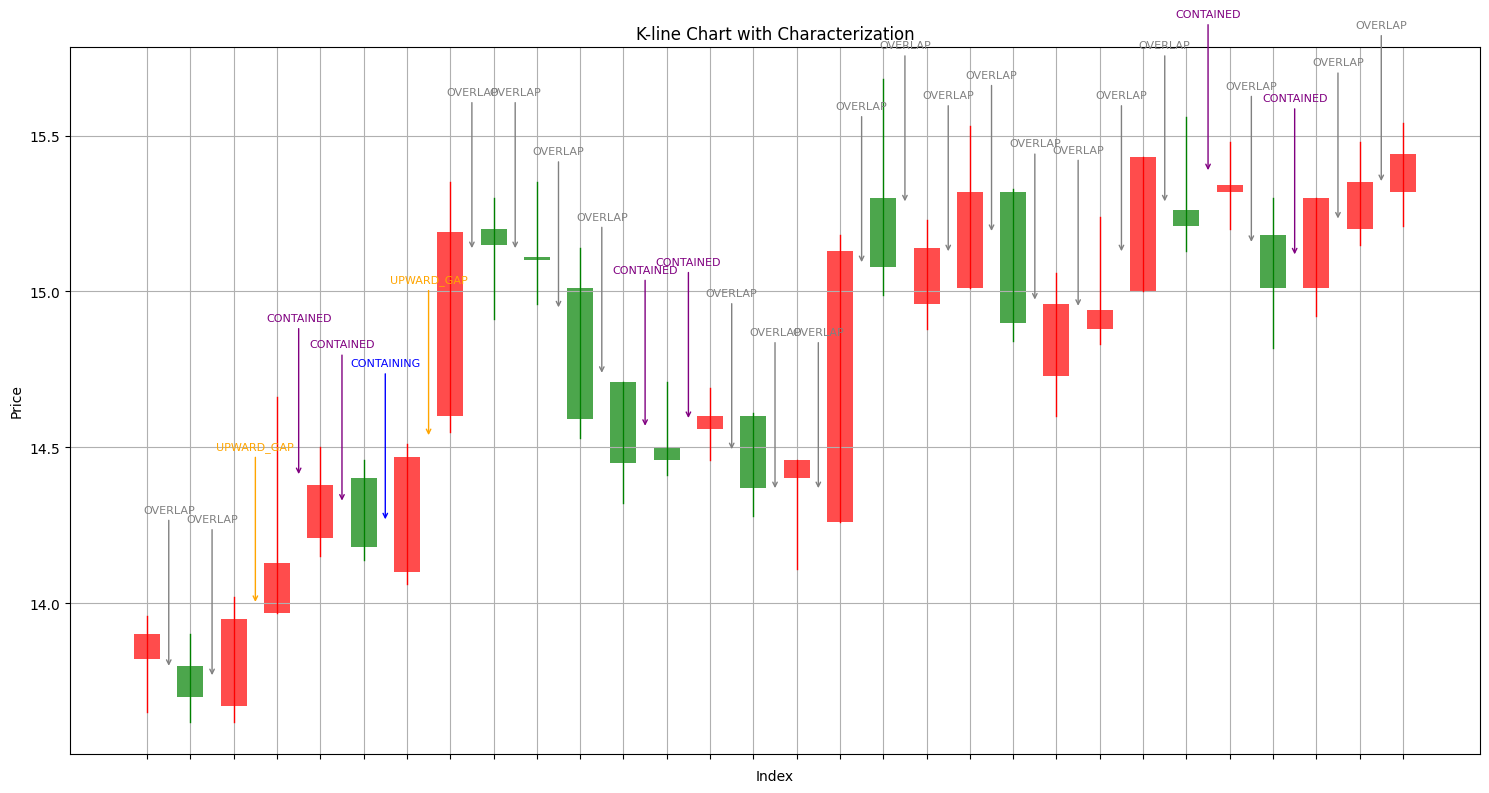

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from enum import Enum
from dataclasses import dataclass
from typing import List, Tuple, Dict, Any
from datetime import datetime
from pathlib import Path
import numpy as np
import argparse
import os
# 定义K线方向枚举
class KLineDirection(Enum):
    BULLISH = 1  # 阳线
    BEARISH = 2  # 阴线
    DOJI = 3     # 十字星

# 定义K线数据结构
@dataclass
class KLine:
    open: float
    close: float
    high: float
    low: float
    timestamp: datetime = None
    
    def __post_init__(self):
        if self.close > self.open:
            self.direction = KLineDirection.BULLISH
        elif self.close < self.open:
            self.direction = KLineDirection.BEARISH
        else:
            self.direction = KLineDirection.DOJI
    
    @property
    def effective_high(self):
        upper_shadow = self.high - max(self.open, self.close)
        return self.high if upper_shadow > (abs(self.close - self.open) * 0.33) else max(self.open, self.close)
    
    @property
    def effective_low(self):
        lower_shadow = min(self.open, self.close) - self.low
        return self.low if lower_shadow > (abs(self.close - self.open) * 0.33) else min(self.open, self.close)

# 定义K线关系枚举
class KLineRelationship(Enum):
    CONTAINING = 1
    CONTAINED = 2
    UPWARD_GAP = 3
    DOWNWARD_GAP = 4
    OVERLAP = 5
    SEPARATE = 6
    NO_RELATIONSHIP = 7

# 从DataFrame创建K线列表
def create_klines_from_df(df):
    klines = []
    for idx, row in df.iterrows():
        kline = KLine(
            open=row['open'],
            close=row['close'],
            high=row['high'],
            low=row['low'],
            timestamp=idx if isinstance(idx, datetime) else None
        )
        klines.append(kline)
    return klines

# 确定两根K线的关系
def determine_relationship(kline1, kline2):
    k1_high, k1_low = kline1.effective_high, kline1.effective_low
    k2_high, k2_low = kline2.effective_high, kline2.effective_low
    
    if k2_low >= k1_low and k2_high <= k1_high:
        return KLineRelationship.CONTAINED
    if k1_low >= k2_low and k1_high <= k2_high:
        return KLineRelationship.CONTAINING
    if k2_low > k1_high:
        return KLineRelationship.UPWARD_GAP
    if k2_high < k1_low:
        return KLineRelationship.DOWNWARD_GAP
    if k2_low > k1_high or k2_high < k1_low:
        return KLineRelationship.SEPARATE
    if k2_low < k1_high and k2_high > k1_low:
        return KLineRelationship.OVERLAP
    return KLineRelationship.NO_RELATIONSHIP

# 计算缺口
def calculate_gap(kline1, kline2):
    upward_gap = max(0, kline2.effective_low - kline1.effective_high)
    downward_gap = max(0, kline1.effective_low - kline2.effective_high)
    gap_type = "upward" if upward_gap > 0 else "downward" if downward_gap > 0 else "none"
    return {"type": gap_type, "upward_gap": upward_gap, "downward_gap": downward_gap, "has_gap": gap_type != "none"}

# 表征两根K线
def characterize_two_klines(kline1, kline2):
    return {
        "relationship": determine_relationship(kline1, kline2).name,
        "gap_info": calculate_gap(kline1, kline2),
        "kline1": {"open": kline1.open, "close": kline1.close, "high": kline1.high, "low": kline1.low},
        "kline2": {"open": kline2.open, "close": kline2.close, "high": kline2.high, "low": kline2.low}
    }

# 递归表征所有K线
def recursive_characterization(klines):
    results = []
    for i in range(1, len(klines)):
        result = characterize_two_klines(klines[i-1], klines[i])
        result["index"] = i
        results.append(result)
    return results

# 绘制K线图并标注表征结果
def plot_klines_with_characterization(df, characterization_results):
    fig, ax = plt.subplots(figsize=(15, 8))
    
    # 绘制K线
    for i, (idx, row) in enumerate(df.iterrows()):
        color = 'red' if row['close'] > row['open'] else 'green'
        ax.plot([i, i], [row['low'], row['high']], color=color, linewidth=1)
        rect = Rectangle((i-0.3, min(row['open'], row['close'])), 0.6, abs(row['close']-row['open']), 
                        facecolor=color, alpha=0.7)
        ax.add_patch(rect)
    
    # 标注表征结果
    color_map = {
        "CONTAINING": "blue", "CONTAINED": "purple", "UPWARD_GAP": "orange",
        "DOWNWARD_GAP": "brown", "OVERLAP": "gray", "SEPARATE": "cyan", "NO_RELATIONSHIP": "black"
    }
    
    for result in characterization_results:
        i = result["index"]
        relationship = result["relationship"]
        mid_x = i - 0.5
        mid_y = (df.iloc[i-1]['high'] + df.iloc[i]['low']) / 2
        color = color_map.get(relationship, "black")
        
        ax.annotate(relationship, xy=(mid_x, mid_y), xytext=(mid_x, mid_y+0.5),
                   arrowprops=dict(arrowstyle="->", color=color), fontsize=8, color=color, ha='center')
    
    # 设置图表属性
    ax.set_xlabel('Index')
    ax.set_ylabel('Price')
    ax.set_title('K-line Chart with Characterization')
    ax.grid(True)
    ax.set_xticks(range(len(df)))
    
    # 设置x轴标签
    if len(df) < 20:
        labels = [d.strftime('%Y-%m-%d') if isinstance(d, datetime) else str(d) for d in df.index]
        ax.set_xticklabels(labels)
    else:
        labels = [d.strftime('%Y-%m-%d') if isinstance(d, datetime) and i%5==0 else '' for i, d in enumerate(df.index)]
        ax.set_xticklabels(labels)
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 主函数
def main():
    ts_code =  "000001.SZ"
    analysis_dir = os.path.join('E:\stock\csv_version','analysis_results')
    csv_path = Path(analysis_dir) / f"{ts_code}_analysis.csv"
    df = pd.read_csv(csv_path, parse_dates=['trade_date'], nrows=30)
    
    # 创建K线列表
    klines = create_klines_from_df(df)
    
    # 进行表征
    characterization_results = recursive_characterization(klines)
    
    # 打印结果
    print("K线表征结果:")
    for i, result in enumerate(characterization_results):
        print(f"K线 {i} 和 {i+1}: {result['relationship']}")
        if result['gap_info']['has_gap']:
            gap_size = result['gap_info']['upward_gap'] or result['gap_info']['downward_gap']
            print(f"  缺口类型: {result['gap_info']['type']}, 大小: {gap_size}")
    
    # 绘制图表
    plot_klines_with_characterization(df, characterization_results)

if __name__ == "__main__":
    main()